Primero importamos el archivo

In [1]:
from google.colab import files
uploaded = files.upload()

Saving cohorte_CLTV_padecimientos.csv to cohorte_CLTV_padecimientos.csv


Vemos que el tipo de dato de cada columna cuadre con el del diccionario y revisamos nulos.

In [31]:
import pandas as pd
pd.set_option('display.max_columns', None)
df = pd.read_csv("cohorte_CLTV_padecimientos.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20860 entries, 0 to 20859
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   persona_hash               20860 non-null  object 
 1   snapshot_date              20860 non-null  object 
 2   snapshot_month             20860 non-null  object 
 3   cltv                       20860 non-null  float64
 4   cltv_1mes                  20860 non-null  float64
 5   frecuencia                 20860 non-null  int64  
 6   compras_previas            20860 non-null  int64  
 7   compras_estimadas          20860 non-null  float64
 8   tiempo_activo              20860 non-null  int64  
 9   permanencia                20860 non-null  int64  
 10  tiempo_vida                20860 non-null  int64  
 11  tiempo_vida_promedio       20860 non-null  int64  
 12  dias_ultima_compra         20860 non-null  int64  
 13  tiempo_entre_compras       20860 non-null  flo

Analizamos variables categoricas

In [32]:
df["segmento"] = df["segmento"].astype("category")
df["genero"] = df["genero"].astype("category")
df["nivel_frecuencia"] = df["nivel_frecuencia"].astype("category")

print(df["segmento"].value_counts(normalize=True))

print(df["genero"].value_counts(normalize=True))

print(df["nivel_frecuencia"].value_counts(normalize=True))


print('-'*80)
print(df[df["genero"] == "NO IDENTIFICADO"].describe())

segmento
NO ASIGNADO     0.415820
31 - 45 AÑOS    0.157670
46 - 60 AÑOS    0.141611
61 - 80 AÑOS    0.139406
19 - 30 AÑOS    0.086337
0 - 18 AÑOS     0.036290
81 > AÑOS       0.022867
Name: proportion, dtype: float64
genero
FEMENINO           0.612656
MASCULINO          0.382598
NO IDENTIFICADO    0.004746
Name: proportion, dtype: float64
nivel_frecuencia
Bajo    1.0
Name: proportion, dtype: float64
--------------------------------------------------------------------------------
               cltv   cltv_1mes  frecuencia  compras_previas  \
count     99.000000   99.000000   99.000000        99.000000   
mean    4416.193433  185.372168    0.080808         1.080808   
std     6738.709640  171.897195    0.273927         0.273927   
min        0.120000    0.008400    0.000000         1.000000   
25%      910.360000   63.725200    0.000000         1.000000   
50%     2065.680000  144.597600    0.000000         1.000000   
75%     4187.970000  233.217540    0.000000         1.000000   
max 

Como casi la mitad de los datos no tienen un segmento asignado lo vamos a tratar como otra categoria. Para el caso de el genero son muy pocos datos de los que no están identificados que podemos eliminarlos del modelo, después de analizar que no vaya a generar un sesgo en otras variables

Para el caso de nivel frecuencia, todos los registros marcan bajo, por lo que vamos a redifinir la variable separando frecuencias muy bajas, mayores a 7 y de 0 como sin recompra

In [36]:
df = df[df['genero'] != 'NO IDENTIFICADO']


# Verificar valores únicos de frecuencia para definir cortes
print(df['frecuencia'].value_counts().sort_index())


df['nivel_frecuencia_v2'] = pd.cut(
    df['frecuencia'],
    bins=[-1, 0, 7, 999],
    labels=['Sin_recompra', 'Baja', 'Media']
)

# Verificar
print(df['nivel_frecuencia_v2'].value_counts().sort_index())
print()
print(df.groupby('nivel_frecuencia_v2', observed=True)['cltv'].median().round(2))

frecuencia
0     18141
1      1105
2       247
3       226
4       197
5       159
6       142
7        81
8        83
9        79
10       51
11       60
12       35
13       32
14       26
15       20
16       18
17       14
18        8
19        6
20        7
21        4
22        1
23        8
25        1
26        3
27        2
28        1
29        1
30        1
37        2
Name: count, dtype: int64
int64
<class 'numpy.int64'>
nivel_frecuencia_v2
Sin_recompra    18141
Baja             2157
Media             463
Name: count, dtype: int64

nivel_frecuencia_v2
Sin_recompra     1843.10
Baja            23253.69
Media           59762.32
Name: cltv, dtype: float64


**No hay nulos en ninguna columna.** Ahora revismaos rangos y percentiles para darme una idea de la distribución de cada dato.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])

,cltv,cltv_1mes,frecuencia,compras_previas,compras_estimadas,tiempo_activo,permanencia,tiempo_vida,tiempo_vida_promedio,dias_ultima_compra,tiempo_entre_compras,monto,monto_previo,monto_estimado,ticket_promedio,valor_anual_promedio,porc_laboratorio,porc_gabinete,nivel_frecuencia_valor,regresan_anualmente
count,20860.000000,20860.000000,20860.000000,20860.000000,20860.000000,20860.000000,20860.000000,20860.000000,20860.000000,20860.000000,20860.000000,20860.000000,20860.000000,20860.000000,20860.0000,20860.000000,20860.000000,20860.000000,2.086000e+04,20860.000000
mean,6565.947037,188.091974,0.520805,1.520805,3.500430,167.718504,181.940460,599.426846,781.367306,14.221956,52.016059,163.309829,2055.739377,1355.585681,1356.9630,5399.889536,71.107344,28.892656,3.012259e-05,0.006040
std,14414.297683,197.643773,2.087151,2.087151,7.872430,575.401333,575.382244,1566.338806,2075.180281,8.142412,235.723839,596.500803,3644.466843,1381.145170,1384.4001,6201.300733,40.769945,40.769945,2.164168e-05,0.077486
min,0.020000,0.001400,0.000000,1.000000,1.000000,0.000000,1.000000,170.000000,200.000000,1.000000,0.000000,0.000000,0.010000,0.010000,0.0100,0.036500,0.000000,0.000000,8.674625e-07,0.000000
1%,162.734000,11.249560,0.000000,1.000000,1.000000,0.000000,1.000000,171.000000,200.000000,1.000000,0.000000,0.000000,80.354000,81.367000,81.3670,200.750000,0.000000,0.000000,2.565986e-06,0.000000
5%,372.420000,22.327200,0.000000,1.000000,1.000000,0.000000,2.000000,173.000000,200.000000,2.000000,0.000000,0.000000,186.210000,186.210000,186.2100,536.177907,0.000000,0.000000,1.361865e-05,0.000000
25%,1048.800000,64.689800,0.000000,1.000000,1.000000,0.000000,8.000000,179.000000,200.000000,7.000000,0.000000,0.000000,519.425000,524.315000,523.8600,1661.407000,41.077645,0.000000,2.739726e-05,0.000000
50%,2218.340000,129.991188,0.000000,1.000000,1.000000,0.000000,16.000000,188.000000,200.000000,14.000000,0.000000,0.000000,1068.710000,1015.393786,998.2700,3367.879724,100.000000,0.000000,2.739726e-05,0.000000
75%,4935.920000,240.390150,0.000000,1.000000,1.000000,0.000000,23.000000,196.000000,200.000000,21.000000,0.000000,0.000000,2168.530000,1649.360000,1663.1450,6793.416500,100.000000,58.922355,2.739726e-05,0.000000
95%,29472.091425,535.090570,3.000000,4.000000,20.516752,1951.150000,1968.000000,3675.050000,5904.600000,28.000000,349.802857,1236.226312,6840.520000,3774.202000,3782.1660,16469.818350,100.000000,100.000000,3.464705e-05,0.000000


In [77]:
# Tabla comparativa de confusores entre cohortes
tabla_confusores = df.groupby('tiene_diabetes_mel_tipo_2').agg(
    n=('cltv', 'count'),
    cltv_medio=('cltv', 'mean'),
    cltv_mediano=('cltv', 'median'),
    frecuencia_media=('frecuencia', 'mean'),
    monto_medio=('monto', 'mean'),
    pct_permanencia_larga=('grupo_permanencia', lambda x: (x == 'larga').mean()),
    pct_regresa_anual=('regresan_anualmente', 'mean')
).round(2)

tabla_confusores.index = ['Sin DM2', 'Con DM2']
tabla_confusores.T

,Sin DM2,Con DM2
n,19909.00,852.00
cltv_medio,6169.19,16086.83
cltv_mediano,2177.94,2860.52
frecuencia_media,0.44,2.47
monto_medio,158.35,291.59
pct_permanencia_larga,0.07,0.22
pct_regresa_anual,0.01,0.01


Viendo esto observamos que la mayoría de registros corresponden a pacientes de una sola compra o inactivos, por lo usaremos la variable que nos indica el nivel de frecuencia

También dividiré dos poblaciones para permanencia ya que existe un gran salto entre los quantiles de 75 y 95 porciento

In [39]:

df['grupo_permanencia'] = np.where(
    df['permanencia'] <= 30,
    'corta',   # pacientes nuevos
    'larga'    # pacientes antiguos
)

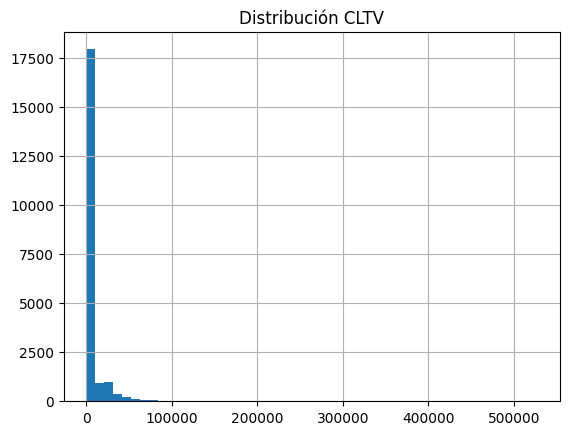

In [ ]:
plt.figure()
df["cltv"].hist(bins=50)
plt.title("Distribución CLTV")
plt.show()

De aqui podemos observar que:

*   La información está muy sesgada hacia valores bajos
*   Posiblemente influida por outliers



In [16]:
print(df["tiene_diabetes_mel_tipo_2"].mean())
print(df["tiene_cancer_mama"].mean())
print(df["tiene_cancer_mama"].mean()*len(df))

df[df["tiene_cancer_mama"] == True].describe()

0.041035474592521576
0.00019175455417066154
4.0


,cltv,cltv_1mes,frecuencia,compras_previas,compras_estimadas,tiempo_activo,permanencia,tiempo_vida,tiempo_vida_promedio,dias_ultima_compra,tiempo_entre_compras,monto,monto_previo,monto_estimado,ticket_promedio,valor_anual_promedio,porc_laboratorio,porc_gabinete,nivel_frecuencia_valor,regresan_anualmente
count,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.0
mean,24042.280134,139.276123,4.750000,5.750000,15.481699,1249.750000,1267.750000,1962.750000,3230.500000,18.000000,134.392045,587.470972,6457.047500,1159.514039,1159.720545,3426.219970,74.011104,25.988896,0.000023,0.0
std,25558.658169,85.423374,5.619905,5.619905,17.051086,1443.960381,1441.850056,2059.657314,3499.341414,9.128709,157.936676,745.715886,6421.134122,622.145201,630.529411,2306.993496,22.779854,22.779854,0.000006,0.0
min,870.680000,60.947600,0.000000,1.000000,1.000000,0.000000,11.000000,171.000000,200.000000,10.000000,0.000000,0.000000,435.340000,435.340000,435.340000,1588.991000,44.956922,0.000000,0.000015,0.0
25%,3003.275000,94.829943,0.000000,1.000000,1.000000,0.000000,24.500000,184.500000,200.000000,10.750000,0.000000,0.000000,1501.637500,783.174598,762.942784,2157.337975,64.873740,15.318889,0.000019,0.0
50%,21936.565063,118.083547,4.000000,5.000000,13.440249,1219.000000,1238.500000,1926.000000,3223.000000,16.500000,116.409091,397.804167,5702.185000,1172.823077,1173.236089,2668.791691,75.543747,24.456253,0.000024,0.0
75%,42975.570197,162.529727,8.750000,9.750000,27.921948,2468.750000,2481.750000,3704.250000,6253.500000,23.750000,250.801136,985.275139,10657.595000,1549.162518,1570.013850,3937.673686,84.681111,35.126260,0.000027,0.0
max,51425.310409,259.989800,11.000000,12.000000,34.046299,2561.000000,2583.000000,3828.000000,6276.000000,29.000000,304.750000,1554.275556,13988.480000,1857.070000,1857.070000,6778.305500,100.000000,55.043078,0.000027,0.0


Hay solo 4 pacientes con cancer de mama. Son muy pocos por eso tomaremos la eliminaremos la variable del modelo por insuficiencia estadística

Iniciamos con una regresión sencilla, GLM
nuestro cltv_ajustado será e^{b_0+ ∑ b_i x_i} siendo x los parametros que tenemos. Ahora empezmos a definir los parametros de nuestro modelo. Vamos a eliminar variables que puedan generar redundancia o que sean derivadas directas de CLTV.

In [50]:

df['genero'] = df['genero'].cat.remove_unused_categories()
print(df['genero'].value_counts())

df['tiene_diabetes_mel_tipo_2'] = df['tiene_diabetes_mel_tipo_2'].astype(int)
print(df['tiene_diabetes_mel_tipo_2'].value_counts())


genero
FEMENINO     12780
MASCULINO     7981
Name: count, dtype: int64
tiene_diabetes_mel_tipo_2
0    19909
1      852
Name: count, dtype: int64


Usamos una matriz de correlación para identificar otras variables que puedan ser redundantes debido a que están muy correlacionadas

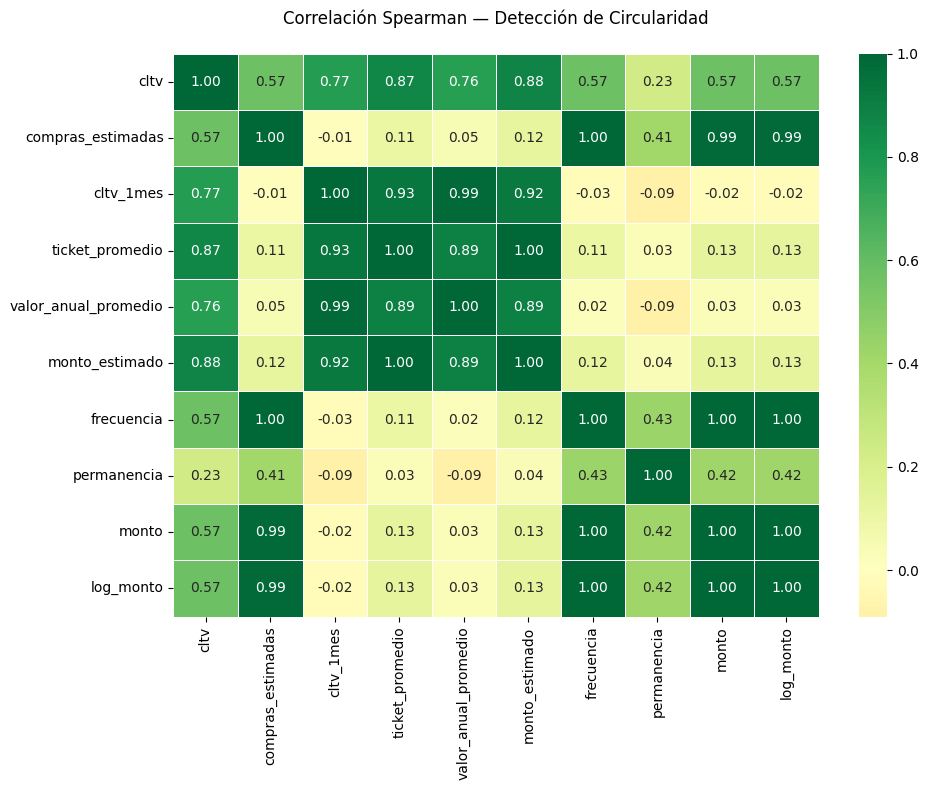

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables candidatas incluyendo cltv para ver circularidad
vars_circularidad = [
    'cltv',
    'compras_estimadas',  # output BG/NBD
    'cltv_1mes',          # derivado de cltv
    'ticket_promedio',    # cltv en numerador
    'valor_anual_promedio', # cltv en numerador
    'monto_estimado',     # output BG/NBD
    'frecuencia',         # input BG/NBD
    'permanencia',        # input BG/NBD
    'monto',              # input legítimo
    'log_monto',          # confusor usado
]

corr = df[vars_circularidad].corr(method='spearman').round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlación Spearman — Detección de Circularidad\n',
             fontsize=12)
plt.tight_layout()
plt.savefig('circularidad.png', dpi=150, bbox_inches='tight')
plt.show()

Ya con los parametros definidos empezamos a construir un modelo

In [58]:
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import glm

# Log del monto histórico (escala y reduce skew)
df['log_monto'] = np.log1p(df['monto'])

# Asegurar que NO ASIGNADO sea categoría explícita en segmento
df['segmento'] = df['segmento'].fillna('NO ASIGNADO').astype(str)

# Convertir categóricas a tipo category para que statsmodels las maneje bien
cat_vars = ['nivel_frecuencia_v2', 'grupo_permanencia', 'segmento', 'genero']
for col in cat_vars:
    df[col] = df[col].astype('category')


# La categoría de referencia es contra la que se interpretan los coeficientes

df['grupo_permanencia'] = df['grupo_permanencia'].cat.reorder_categories(
    ['corta', 'larga'], ordered=False
)


#Hacemos un modelo baseline

formula_baseline = """
    cltv ~ nivel_frecuencia_v2
         + grupo_permanencia
         + log_monto
         + C(segmento)
         + C(genero)
         + regresan_anualmente
"""

modelo_baseline = glm(
    formula=formula_baseline,
    data=df,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print("=== MODELO BASELINE ===")
print(modelo_baseline.summary())

# Ajustamos baseline

formula_ajustado = """
    cltv ~ nivel_frecuencia_v2
         + grupo_permanencia
         + log_monto
         + C(segmento)
         + C(genero)
         + regresan_anualmente
         + tiene_diabetes_mel_tipo_2
"""

modelo_ajustado = glm(
    formula=formula_ajustado,
    data=df,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print("\n=== MODELO AJUSTADO ===")
print(modelo_ajustado.summary())

=== MODELO BASELINE ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   cltv   No. Observations:                20761
Model:                            GLM   Df Residuals:                    20748
Model Family:                   Gamma   Df Model:                           12
Link Function:                    Log   Scale:                          1.0379
Method:                          IRLS   Log-Likelihood:            -1.9141e+05
Date:                Thu, 05 Mar 2026   Deviance:                       16568.
Time:                        03:13:52   Pearson chi2:                 2.15e+04
No. Iterations:                    25   Pseudo R-squ. (CS):             0.6721
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [62]:
# CLTV ajustado como valor esperado del GLM condicionado a confusores
df['cltv_ajustado'] = modelo_ajustado.predict(df)


print("CLTV original:")
print(df['cltv'].describe().round(2))
print("\nCLTV ajustado:")
print(df['cltv_ajustado'].describe().round(2))

# correlación de Spearman
from scipy.stats import spearmanr
rho, pval = spearmanr(df['cltv'], df['cltv_ajustado'])
print(f"\nSpearman: {rho:.4f}")

# Comparar medias por cohorte
print("\nCLTV original por cohorte DM2:")
print(df.groupby('tiene_diabetes_mel_tipo_2')['cltv'].agg(['mean','median']).round(2))

print("\nCLTV ajustado por cohorte DM2:")
print(df.groupby('tiene_diabetes_mel_tipo_2')['cltv_ajustado'].agg(['mean','median']).round(2))


df['delta_cltv'] = df['cltv_ajustado'] - df['cltv']
df['ratio_cltv'] = df['cltv_ajustado'] / df['cltv']
print(df.groupby('tiene_diabetes_mel_tipo_2')['ratio_cltv'].mean())
print(df.groupby('tiene_padecimientos')[['cltv','cltv_ajustado']].mean())

CLTV original:
count     20761.00
mean       6576.20
std       14440.44
min           0.02
25%        1050.68
50%        2218.96
75%        4936.90
max      527167.92
Name: cltv, dtype: float64

CLTV ajustado:
count     20761.00
mean       6536.41
std       11892.40
min        2556.99
25%        2635.45
50%        2643.92
75%        3017.37
max      116607.78
Name: cltv_ajustado, dtype: float64

Spearman: 0.3906

CLTV original por cohorte DM2:
                               mean   median
tiene_diabetes_mel_tipo_2                   
0                           6169.19  2177.94
1                          16086.83  2860.52

CLTV ajustado por cohorte DM2:
                               mean   median
tiene_diabetes_mel_tipo_2                   
0                           6184.51  2643.92
1                          14759.19  3029.33
tiene_diabetes_mel_tipo_2
0    210.630676
1     85.133412
Name: ratio_cltv, dtype: float64
                             cltv  cltv_ajustado
tiene_padecimientos 

In [64]:
df_temp = df.copy()
df_temp["tiene_diabetes_mel_tipo_2"] = 0

pred_base = modelo_ajustado.predict(df_temp)
pred_actual = modelo_ajustado.predict(df)

factor = pred_actual / pred_base

df["cltv_ajustado"] = df["cltv"] * factor

# correlación de Spearman
rho, pval = spearmanr(df['cltv'], df['cltv_ajustado'])
print(f"\nSpearman: {rho:.4f}")

# Comparar medias por cohorte
print("\nCLTV original por cohorte DM2:")
print(df.groupby('tiene_diabetes_mel_tipo_2')['cltv'].agg(['mean','median']).round(2))

print("\nCLTV ajustado por cohorte DM2:")
print(df.groupby('tiene_diabetes_mel_tipo_2')['cltv_ajustado'].agg(['mean','median']).round(2))


df['delta_cltv'] = df['cltv_ajustado'] - df['cltv']
df['ratio_cltv'] = df['cltv_ajustado'] / df['cltv']
print(df.groupby('tiene_diabetes_mel_tipo_2')['ratio_cltv'].mean())
print(df.groupby('tiene_padecimientos')[['cltv','cltv_ajustado']].mean())


Spearman: 1.0000

CLTV original por cohorte DM2:
                               mean   median
tiene_diabetes_mel_tipo_2                   
0                           6169.19  2177.94
1                          16086.83  2860.52

CLTV ajustado por cohorte DM2:
                               mean   median
tiene_diabetes_mel_tipo_2                   
0                           6169.19  2177.94
1                          16150.63  2871.86
tiene_diabetes_mel_tipo_2
0    1.000000
1    1.003966
Name: ratio_cltv, dtype: float64
                             cltv  cltv_ajustado
tiene_padecimientos                             
Con padecimiento     16124.009699   16187.505259
Sin padecimiento      6165.601595    6165.601595


/tmp/ipykernel_542/213786048.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = df.groupby(['segmento','tiene_diabetes_mel_tipo_2'])['cltv'].median().unstack()


<Figure size 800x500 with 0 Axes>

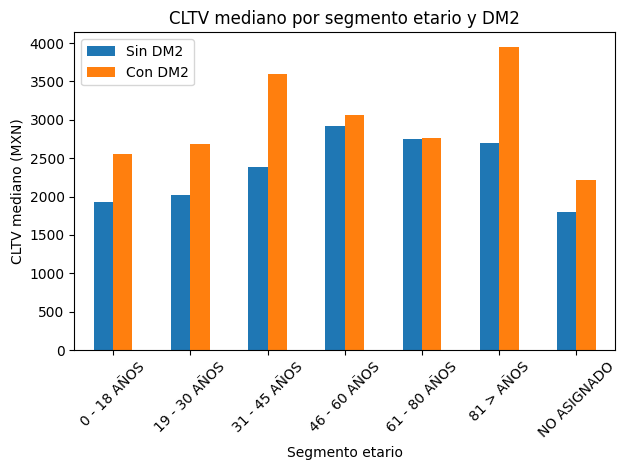

In [68]:
plt.figure(figsize=(8,5))

res = df.groupby(['segmento','tiene_diabetes_mel_tipo_2'])['cltv'].median().unstack()

res.plot(kind='bar')

plt.title('CLTV mediano por segmento etario y DM2')
plt.ylabel('CLTV mediano (MXN)')
plt.xlabel('Segmento etario')
plt.legend(['Sin DM2','Con DM2'])

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

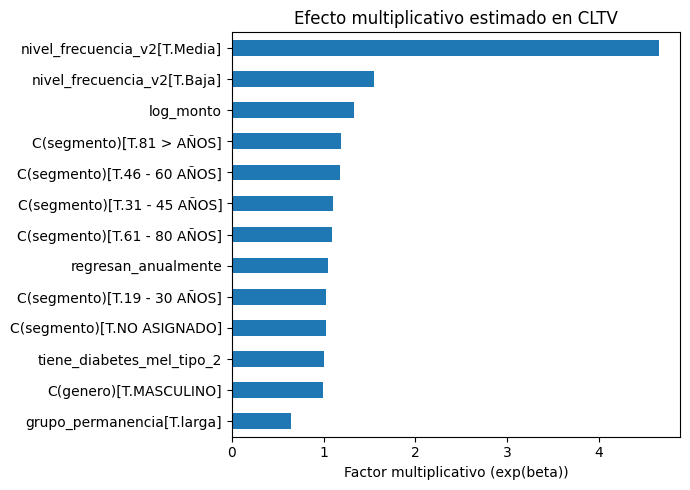

In [69]:
import numpy as np

coef = modelo_ajustado.params.drop('Intercept')
coef = np.exp(coef)

coef.sort_values().plot(kind='barh', figsize=(7,5))

plt.title('Efecto multiplicativo estimado en CLTV')
plt.xlabel('Factor multiplicativo (exp(beta))')
plt.tight_layout()
plt.show()

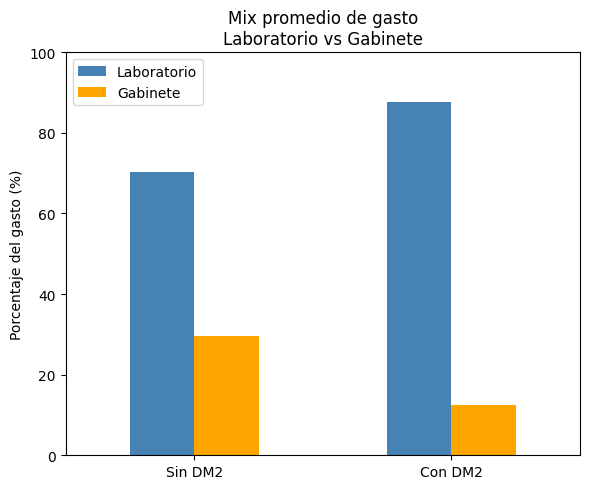

In [74]:
import matplotlib.pyplot as plt

mix = df.groupby('tiene_diabetes_mel_tipo_2')[['porc_laboratorio','porc_gabinete']].mean()

mix.plot(
    kind='bar',
    figsize=(6,5),
    color=['steelblue','orange']
)

plt.title('Mix promedio de gasto\nLaboratorio vs Gabinete')
plt.ylabel('Porcentaje del gasto (%)')
plt.xlabel('')
plt.xticks([0,1], ['Sin DM2','Con DM2'], rotation=0)
plt.legend(['Laboratorio','Gabinete'])

plt.ylim(0,100)

plt.tight_layout()
plt.show()

/tmp/ipykernel_542/1425145503.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mix_seg = df.groupby('segmento')[['porc_laboratorio','porc_gabinete']].mean()


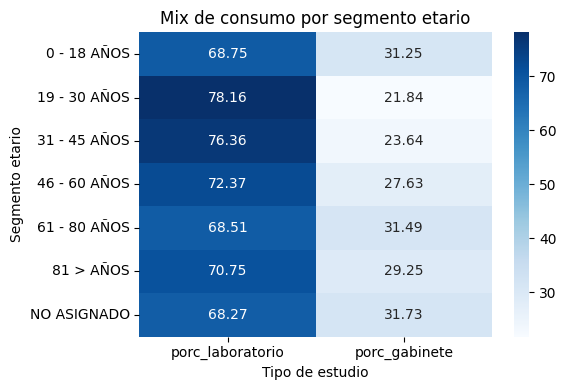

In [71]:
import seaborn as sns

mix_seg = df.groupby('segmento')[['porc_laboratorio','porc_gabinete']].mean()

plt.figure(figsize=(6,4))

sns.heatmap(
    mix_seg,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Mix de consumo por segmento etario')
plt.ylabel('Segmento etario')
plt.xlabel('Tipo de estudio')

plt.tight_layout()
plt.show()